# PyTorch FashionMNIST Classification

## Phase 1 - Problem Definition

### Objective

The objective is to build a PyTorch image classifier that assigns each FashionMNIST image to one of 10 apparel categories. This is a supervised, single-label, multi-class classification problem.

### Task Formulation

- **Input:** a `28 x 28` grayscale image represented as a tensor with shape `[1, 28, 28]`.
- **Target:** one integer class label in the range `[0, 9]` (T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).
- **Model output:** 10 raw logits, one for each FashionMNIST class.
- **Primary metric:** classification accuracy.
- **Optimization objective:** minimize cross-entropy loss on training data.

### Evaluation Protocol

The official FashionMNIST training pool is divided once with a fixed seed using a class-stratified 90/10 split:

- **Offical Training subset:** 60,000 images used for preprocessing statistics, optimization and controlled experiments.
- **Official test set:** 10,000 images kept untouched until one final evaluation after all modeling decisions are fixed.

EDA may inspect the labeled official training pool before the split because it does not fit model parameters. Preprocessing statistics are computed only from the 60,000-image training subset. Validation and test images use the same deterministic transform and never receive random augmentation.

### Success Criteria

A valid solution must implement the complete PyTorch workflow: load and preprocess data, build a neural network, train with forward and backward passes, compare controlled experiments using validation metrics, evaluate the selected model once on the untouched test set, visualize learning behavior and predictions, and save then reload the selected model. Results are trustworthy only when the official test set remains isolated from preprocessing, optimization and model selection.

## Phase 2 - Environment Setup

This phase records the execution environment and imports the libraries required by the complete workflow.

In [10]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
PROJECT_CANDIDATES = (
    CURRENT_DIR,
    CURRENT_DIR / 'total_practice' / 'practice_1',
)
PROJECT_DIR = next(
    (path for path in PROJECT_CANDIDATES if (path / 'practice_1.ipynb').exists()),
    CURRENT_DIR,
)
DATA_DIR = PROJECT_DIR / 'data'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
RUNS_DIR = PROJECT_DIR / 'runs'

if str(PROJECT_DIR.parent) not in sys.path:
    sys.path.append(str(PROJECT_DIR.parent))

In [11]:
%matplotlib inline
import sys
import torch
import torchvision
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

Python version: 3.11.9
PyTorch version: 2.13.0+cpu
TorchVision version: 0.28.0+cpu
CUDA available: False
MPS available: False


In [12]:
import random
import time
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from typing import Dict, List, Optional, Sequence

## Phase 3 - Data Loading

FashionMNIST is loaded from TorchVision using the two official partitions defined by the dataset.

- **Official training pool:** 60,000 labeled images used for EDA before a reproducible train/validation split.
- **Official test set:** 10,000 labeled images reserved for one final evaluation.

At this stage, `ToTensor()` is the only transform. It converts each PIL image to a `torch.float32` tensor with shape `[1, 28, 28]` and scales pixel values from `[0, 255]` to `[0, 1]`. The class-stratified split and final transforms are created in Phase 5 so that EDA observes original images while validation and test inputs remain deterministic.

In [13]:
SEED = 42
raw_transform = transforms.ToTensor()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=raw_transform,
)
test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=raw_transform,
)
class_names = train_dataset.classes

print(f'Official training pool: {len(train_dataset):,}')
print(f'Official test set: {len(test_dataset):,}')

100%|██████████| 26.4M/26.4M [00:05<00:00, 4.92MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 127kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.21MB/s]

Official training pool: 60,000
Official test set: 10,000


## Phase 4 - Exploratory Data Analysis

EDA is performed **only on the official training set**. The official test set is excluded so that observations made during development cannot influence final evaluation.

The analysis checks dataset structure, class frequencies, pixel statistics, basic data quality and representative image-label pairs. Its purpose is to validate assumptions needed by the model and preprocessing pipeline.

### Data Overview

First, inspect the official partition sizes and one training sample. The expected sample is a single-channel `28 x 28` floating-point tensor. These checks establish the input dimensions required by the neural network.

In [14]:
print(f'Number of images in Train set: {len(train_dataset)}')
print(f'Number of images in Test set: {len(test_dataset)}')

Number of images in Train set: 60000
Number of images in Test set: 10000


In [15]:
image, label = train_dataset[0]
channels, height, width = image.shape
aspect_ratio = width / height

In [16]:
print(f" - Resolution: {width}x{height} pixels")
print(f" - Aspect Ratio: {width}:{height} (Equivalent to {aspect_ratio:.1f}:1)")

 - Resolution: 28x28 pixels
 - Aspect Ratio: 28:28 (Equivalent to 1.0:1)


In [17]:
print(f"Image size (Channels x Height x Width): {image.shape}")
print(f"Image data type: {image.dtype}")

Image size (Channels x Height x Width): torch.Size([1, 28, 28])
Image data type: torch.float32


In [18]:
if channels == 1:
    print(f" - Color Channels: {channels} (Grayscale format)")
elif channels == 3:
    print(f" - Color Channels: {channels} (RGB format)")
else:
    print(f" - Color Channels: {channels} (Unusual format)")

 - Color Channels: 1 (Grayscale format)


### Class and Pixel Distribution

Class counts verify the balance of the official training set. Pixel mean and standard deviation summarize the intensity distribution before augmentation and normalization.

In [19]:
train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

In [20]:
for class_idx, count in sorted(class_counts.items()):
    class_name = class_names[class_idx]
    print(f' - Class {class_idx} ({class_name}): {count} ảnh')

 - Class 0 (T-shirt/top): 6000 ảnh
 - Class 1 (Trouser): 6000 ảnh
 - Class 2 (Pullover): 6000 ảnh
 - Class 3 (Dress): 6000 ảnh
 - Class 4 (Coat): 6000 ảnh
 - Class 5 (Sandal): 6000 ảnh
 - Class 6 (Shirt): 6000 ảnh
 - Class 7 (Sneaker): 6000 ảnh
 - Class 8 (Bag): 6000 ảnh
 - Class 9 (Ankle boot): 6000 ảnh


In [21]:
all_images = torch.stack([img for img, _ in train_dataset])
mean_val = all_images.mean().item()
std_val = all_images.std().item()

In [22]:
print(f"\nMean Pixel Value: {mean_val:.4f}")
print(f"Pixel Std Deviation: {std_val:.4f}")


Mean Pixel Value: 0.2860
Pixel Std Deviation: 0.3530


### Data Quality Checks

The official training set is scanned for NaN values and extreme all-black or all-white images. Extreme images are treated as suspicious observations for review rather than automatic proof of corruption.

In [23]:
corrupted_count = 0
nan_images = 0
black_images = 0
white_images = 0

In [24]:
for idx in range(len(train_dataset)):
    img, _ = train_dataset[idx]
    
    if torch.isnan(img).any():
        nan_images += 1
        corrupted_count += 1
        
    elif torch.max(img) == 0.0:
        black_images += 1
        corrupted_count += 1
        
    elif torch.min(img) == 1.0:
        white_images += 1
        corrupted_count += 1

In [25]:
print(f"Total images in Train set: {len(train_dataset)} images")
print(f"Number of corrupted images detected: {corrupted_count} images")

Total images in Train set: 60000 images
Number of corrupted images detected: 0 images


### Visual Sample Inspection

A reproducible shuffled batch is displayed with its class labels. This visual sanity check confirms that image orientation, grayscale rendering and label mapping are plausible before preprocessing and training.

In [26]:
sample_generator = torch.Generator().manual_seed(SEED)
train_loader_sample = DataLoader(
    train_dataset,
    batch_size=20,
    shuffle=True,
    generator=sample_generator,
)
dataiter = iter(train_loader_sample)
images, labels = next(dataiter)

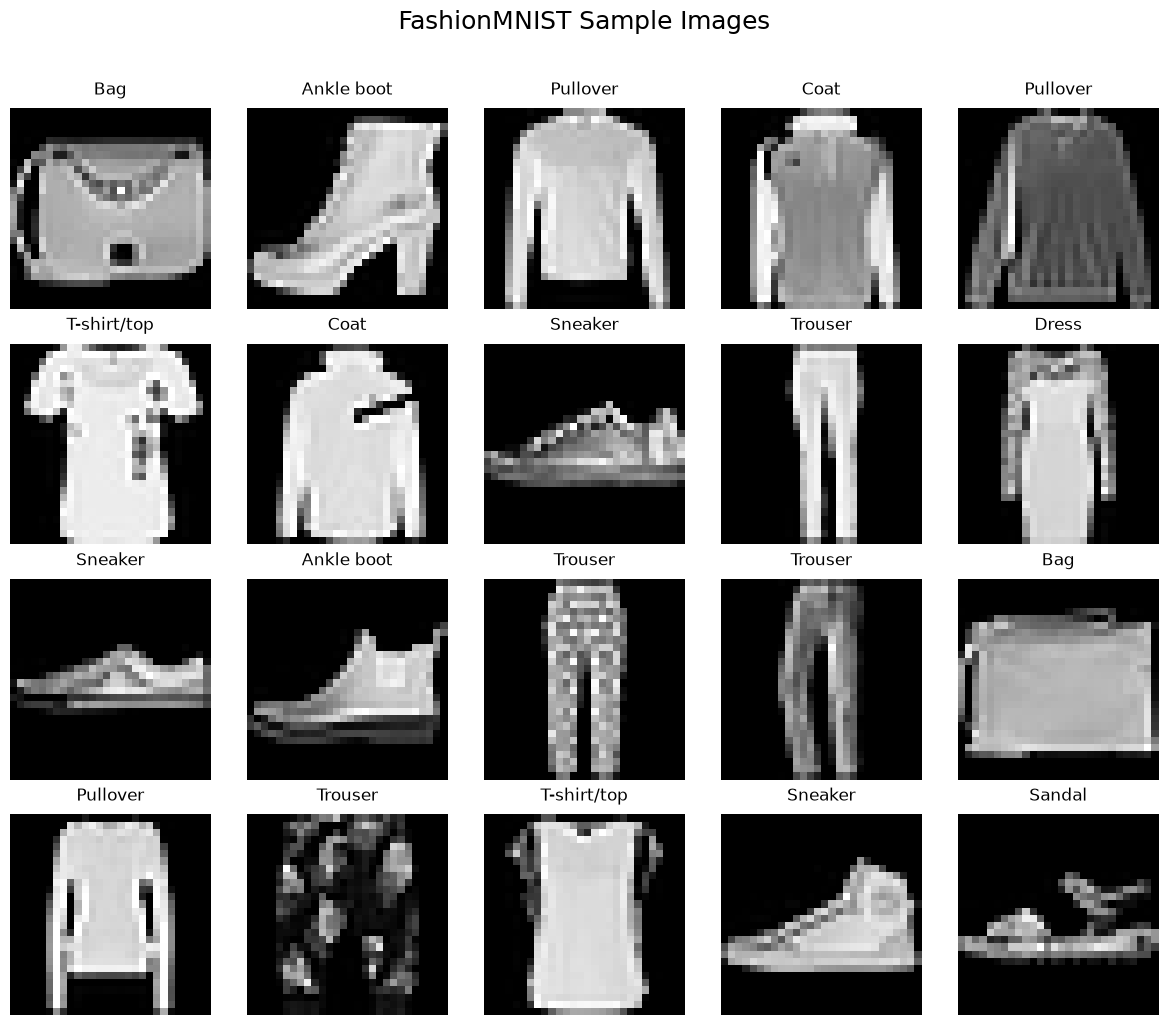

In [27]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(12, 10))
fig.suptitle('FashionMNIST Sample Images', fontsize=18, y=1.02)

for idx, ax in enumerate(axes.flatten()):
    img = images[idx].squeeze().numpy()
    label_name = class_names[labels[idx]]
    
    ax.imshow(img, cmap='gray')
    
    ax.set_title(label_name, fontsize=12, pad=10)
    
    ax.axis('off')

plt.tight_layout()
plt.show()

## Phase 5 - Data Preprocessing

The 60,000-image official training pool is divided with a fixed, class-stratified 90/10 split. This creates 54,000 training samples and 6,000 validation samples while preserving exactly 10% of every class for validation. The official 10,000-image test set remains separate.

Normalization statistics are computed only from the training indices. The baseline transform is deterministic so architecture and optimizer experiments remain controlled. A separate augmented training dataset is prepared for an explicit augmentation experiment. Validation and test transforms contain no random operations.

### Split and Transform Strategy

The split is created before transformed datasets and DataLoaders. Separate FashionMNIST instances allow training, validation and test samples to use independent transform policies without sharing stochastic augmentation.

- Baseline training: tensor conversion and training-subset normalization.
- Augmented training experiment: horizontal flip, small rotation, tensor conversion and the same normalization.
- Validation and test: deterministic tensor conversion and the same normalization.

This structure prevents validation augmentation, train/validation overlap and official-test leakage.

![Preprocessing UML — stratified split, transform, DataLoader](diagrams/01_preprocessing.png)

In [28]:
VALIDATION_RATIO = 0.10
split_generator = torch.Generator().manual_seed(SEED)
targets = train_dataset.targets
train_index_parts = []
validation_index_parts = []

for class_index in range(len(class_names)):
    class_indices = torch.where(targets == class_index)[0]
    class_order = torch.randperm(len(class_indices), generator=split_generator)
    shuffled_indices = class_indices[class_order]
    validation_count = int(len(class_indices) * VALIDATION_RATIO)
    validation_index_parts.append(shuffled_indices[:validation_count])
    train_index_parts.append(shuffled_indices[validation_count:])

train_indices = torch.cat(train_index_parts)
validation_indices = torch.cat(validation_index_parts)
train_indices = train_indices[
    torch.randperm(len(train_indices), generator=split_generator)
]
validation_indices = validation_indices[
    torch.randperm(len(validation_indices), generator=split_generator)
]

training_pixels = train_dataset.data[train_indices].to(torch.float32).div(255.0)
TRAIN_MEAN = training_pixels.mean().item()
TRAIN_STD = training_pixels.std().item()
del training_pixels

baseline_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

print(f'Training mean: {TRAIN_MEAN:.6f}')
print(f'Training std: {TRAIN_STD:.6f}')

Training mean: 0.286139
Training std: 0.353084


### Dataset Construction

Three independent views of the official training pool are created. Training and validation subsets use disjoint indices, while separate parent datasets enforce their transform contracts. The augmented view reuses only training indices and is reserved for a controlled experiment.

In [29]:
baseline_training_pool = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=baseline_transform,
)
augmented_training_pool = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=augmented_transform,
)
validation_pool = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=evaluation_transform,
)
test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=evaluation_transform,
)

train_subset = Subset(baseline_training_pool, train_indices.tolist())
augmented_train_subset = Subset(
    augmented_training_pool,
    train_indices.tolist(),
)
validation_subset = Subset(
    validation_pool,
    validation_indices.tolist(),
)

### DataLoaders

The baseline loader shuffles only the training subset. Validation and test loaders preserve deterministic ordering. A loader factory is introduced later in the training phase so every controlled experiment receives a fresh shuffle generator.

In [30]:
BATCH_SIZE = 64
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
)
validation_loader = DataLoader(
    validation_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

### Pipeline Sanity Checks

Before model construction, the split, class balance, transforms and loader contracts are verified. Expected batches contain `float32` images with shape `[B, 1, 28, 28]` and `int64` labels with shape `[B]`. Validation samples must be deterministic and the official test set must remain independent.

In [31]:
assert len(train_subset) == 54_000
assert len(augmented_train_subset) == 54_000
assert len(validation_subset) == 6_000
assert len(test_dataset) == 10_000
assert len(set(train_indices.tolist()).intersection(validation_indices.tolist())) == 0
assert len(torch.unique(torch.cat((train_indices, validation_indices)))) == 60_000

train_class_counts = torch.bincount(targets[train_indices], minlength=10)
validation_class_counts = torch.bincount(
    targets[validation_indices],
    minlength=10,
)

assert torch.equal(train_class_counts, torch.full((10,), 5_400))
assert torch.equal(validation_class_counts, torch.full((10,), 600))

validation_image_a, validation_label_a = validation_subset[0]
validation_image_b, validation_label_b = validation_subset[0]
assert torch.equal(validation_image_a, validation_image_b)
assert validation_label_a == validation_label_b

print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(validation_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 844
Validation batches: 94
Test batches: 157


In [32]:
train_images, train_labels = next(iter(train_loader))
validation_images, validation_labels = next(iter(validation_loader))
test_images, test_labels = next(iter(test_loader))

for split_name, images, labels in (
    ('Train', train_images, train_labels),
    ('Validation', validation_images, validation_labels),
    ('Test', test_images, test_labels),
):
    assert images.ndim == 4
    assert images.shape[1:] == (1, 28, 28)
    assert images.dtype == torch.float32
    assert labels.ndim == 1
    assert labels.dtype == torch.int64
    assert torch.isfinite(images).all()
    print(
        f'{split_name}: images={tuple(images.shape)}, '
        f'labels={tuple(labels.shape)}, '
        f'range=[{images.min().item():.3f}, {images.max().item():.3f}]'
    )

Train: images=(64, 1, 28, 28), labels=(64,), range=[-0.810, 2.022]
Validation: images=(64, 1, 28, 28), labels=(64,), range=[-0.810, 2.022]
Test: images=(64, 1, 28, 28), labels=(64,), range=[-0.810, 2.022]


## Phase 6 - Model Building

The baseline is a configurable multi-layer perceptron. It converts each normalized `1 x 28 x 28` image into a flat 784-feature vector and returns one raw logit for each of the 10 classes.

The model intentionally excludes Softmax because `CrossEntropyLoss` consumes raw logits. Constructor validation protects architecture configuration, while runtime tensor compatibility is verified once by a fail-fast sanity check before training.

![Preprocessing UML — stratified split, transform, DataLoader](diagrams/02_model_building.png)

In [33]:
class FashionMNISTModel(nn.Module):
    def __init__(
        self,
        hidden_dims: Optional[Sequence[int]] = None,
        dropout: float = 0.0,
        num_classes: int = 10,
        input_dim: int = 28 * 28,
    ):
        super().__init__()
        resolved_hidden_dims = (
            (128,) if hidden_dims is None else tuple(hidden_dims)
        )

        if input_dim <= 0:
            raise ValueError('input_dim must be positive')
        if num_classes <= 1:
            raise ValueError('num_classes must be greater than one')
        if any(hidden_dim <= 0 for hidden_dim in resolved_hidden_dims):
            raise ValueError('hidden dimensions must be positive')
        if not 0.0 <= dropout < 1.0:
            raise ValueError('dropout must be in the interval [0, 1)')

        layers: List[nn.Module] = [nn.Flatten()]
        in_features = input_dim

        for hidden_dim in resolved_hidden_dims:
            layers.extend((nn.Linear(in_features, hidden_dim), nn.ReLU()))
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, num_classes))

        self.network = nn.Sequential(*layers)
        self.hidden_dims = resolved_hidden_dims
        self.dropout = dropout
        self.num_classes = num_classes
        self.input_dim = input_dim

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.network(inputs)

In [34]:
BASELINE_CONFIG = {
    'experiment_id': 'E0_baseline',
    'hidden_dims': (128,),
    'dropout': 0.0,
    'num_classes': 10,
    'input_dim': 28 * 28,
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'weight_decay': 0.0,
    'batch_size': BATCH_SIZE,
    'epochs': 10,
    'use_augmentation': False,
}


def build_model(config: Dict) -> FashionMNISTModel:
    return FashionMNISTModel(
        hidden_dims=config['hidden_dims'],
        dropout=config['dropout'],
        num_classes=config['num_classes'],
        input_dim=config['input_dim'],
    )


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


model = build_model(BASELINE_CONFIG)
parameter_count = count_trainable_parameters(model)

print(model)
print(f'Trainable parameters: {parameter_count:,}')

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 101,770


In [35]:
def sanity_check_model(
    model: FashionMNISTModel,
    images: torch.Tensor,
    labels: torch.Tensor,
) -> Dict:
    sanity_model = build_model({
        'hidden_dims': model.hidden_dims,
        'dropout': model.dropout,
        'num_classes': model.num_classes,
        'input_dim': model.input_dim,
    })
    sanity_model.train()
    sanity_images = images[:8]
    sanity_labels = labels[:8]

    parameter = next(sanity_model.parameters())
    assert sanity_images.shape == (8, 1, 28, 28)
    assert sanity_images.dtype == parameter.dtype
    assert sanity_images.device == parameter.device
    assert sanity_labels.shape == (8,)
    assert sanity_labels.dtype == torch.int64

    logits = sanity_model(sanity_images)
    assert logits.shape == (8, sanity_model.num_classes)
    assert torch.isfinite(logits).all()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(sanity_model.parameters(), lr=0.01)
    loss = criterion(logits, sanity_labels)
    assert torch.isfinite(loss)

    parameter_snapshot = {
        name: value.detach().clone()
        for name, value in sanity_model.named_parameters()
    }

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    gradients = [
        parameter.grad
        for parameter in sanity_model.parameters()
        if parameter.requires_grad
    ]
    assert all(gradient is not None for gradient in gradients)
    assert all(torch.isfinite(gradient).all() for gradient in gradients)
    assert any(gradient.abs().sum().item() > 0 for gradient in gradients)

    optimizer.step()

    parameters_changed = any(
        not torch.equal(
            parameter_snapshot[name],
            parameter.detach(),
        )
        for name, parameter in sanity_model.named_parameters()
    )
    assert parameters_changed

    return {
        'output_shape': tuple(logits.shape),
        'loss': loss.item(),
        'gradients_finite': True,
        'parameters_changed': parameters_changed,
    }


MODEL_SANITY = sanity_check_model(model, train_images, train_labels)

assert parameter_count == 101_770
print(f"Output shape: {MODEL_SANITY['output_shape']}")
print(f"Finite loss: {MODEL_SANITY['loss']:.6f}")
print(f"Gradients finite: {MODEL_SANITY['gradients_finite']}")
print(f"Parameters changed: {MODEL_SANITY['parameters_changed']}")

Output shape: (8, 10)
Finite loss: 2.312276
Gradients finite: True
Parameters changed: True


## Phase 7 - Model Training

Every training run starts from fresh model and optimizer state. The training subset is optimized with `CrossEntropyLoss`, while the deterministic validation subset is evaluated after every epoch. Validation accuracy selects the checkpoint for each experiment; the official test loader is not accepted by any training function.

Epoch loss is a sample-weighted mean, accuracy is stored as a fraction in `[0, 1]`, and TensorBoard receives the same metrics recorded in the returned history.

![Training UML — epoch loop and checkpoint selection](diagrams/03_training_epoch.png)

In [ ]:
def set_reproducibility(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def select_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


device = select_device()
print(f'Selected device: {device}')

Selected device: cpu


In [ ]:
def make_train_loader(
    dataset,
    batch_size: int,
    seed: int,
) -> DataLoader:
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )


def build_optimizer(
    model: nn.Module,
    config: Dict,
) -> torch.optim.Optimizer:
    optimizer_name = config['optimizer'].lower()
    learning_rate = config['learning_rate']
    weight_decay = config.get('weight_decay', 0.0)

    if optimizer_name == 'adam':
        return optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )
    if optimizer_name == 'sgd':
        return optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=config.get('momentum', 0.9),
            weight_decay=weight_decay,
        )
    raise ValueError(f'Unsupported optimizer: {config["optimizer"]}')

In [ ]:
def evaluate_loader(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Dict[str, float]:
    model.eval()
    loss_sum = 0.0
    correct = 0
    sample_count = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            batch_size = labels.size(0)

            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite evaluation loss')

            loss_sum += loss.item() * batch_size
            correct += logits.argmax(dim=1).eq(labels).sum().item()
            sample_count += batch_size

    if sample_count == 0:
        raise ValueError('Evaluation loader is empty')

    return {
        'loss': loss_sum / sample_count,
        'accuracy': correct / sample_count,
        'sample_count': sample_count,
    }

In [ ]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> Dict[str, float]:
    model.train()
    loss_sum = 0.0
    correct = 0
    sample_count = 0
    started_at = time.perf_counter()

    for batch_index, (images, labels) in enumerate(data_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f'Non-finite training loss at batch {batch_index}'
            )

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += logits.argmax(dim=1).eq(labels).sum().item()
        sample_count += batch_size

    if sample_count == 0:
        raise ValueError('Training loader is empty')

    return {
        'loss': loss_sum / sample_count,
        'accuracy': correct / sample_count,
        'sample_count': sample_count,
        'elapsed_seconds': time.perf_counter() - started_at,
    }

![Training UML — batch-level detail of train_one_epoch()](diagrams/04_training_batch.png)

In [ ]:
def run_training(
    config: Dict,
    training_dataset,
    validation_loader: DataLoader,
    device: torch.device,
    log_directory: Optional[Path] = None,
    verbose: bool = True,
) -> Dict:
    set_reproducibility(config.get('seed', SEED))
    model = build_model(config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, config)
    train_loader = make_train_loader(
        training_dataset,
        batch_size=config['batch_size'],
        seed=config.get('seed', SEED),
    )
    writer = (
        SummaryWriter(log_dir=str(log_directory))
        if log_directory is not None
        else None
    )
    history = []
    best_state = None
    best_epoch = 0
    best_validation_accuracy = -1.0
    best_validation_loss = float('inf')
    started_at = time.perf_counter()

    try:
        for epoch in range(1, config['epochs'] + 1):
            train_metrics = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                device,
            )
            validation_metrics = evaluate_loader(
                model,
                validation_loader,
                criterion,
                device,
            )
            learning_rate = optimizer.param_groups[0]['lr']
            epoch_record = {
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'train_accuracy': train_metrics['accuracy'],
                'validation_loss': validation_metrics['loss'],
                'validation_accuracy': validation_metrics['accuracy'],
                'learning_rate': learning_rate,
                'elapsed_seconds': train_metrics['elapsed_seconds'],
            }
            history.append(epoch_record)

            validation_is_better = (
                validation_metrics['accuracy'] > best_validation_accuracy
                or (
                    validation_metrics['accuracy']
                    == best_validation_accuracy
                    and validation_metrics['loss'] < best_validation_loss
                )
            )
            if validation_is_better:
                best_epoch = epoch
                best_validation_accuracy = validation_metrics['accuracy']
                best_validation_loss = validation_metrics['loss']
                best_state = {
                    name: value.detach().cpu().clone()
                    for name, value in model.state_dict().items()
                }

            if writer is not None:
                writer.add_scalar(
                    'Loss/Train',
                    train_metrics['loss'],
                    epoch,
                )
                writer.add_scalar(
                    'Loss/Validation',
                    validation_metrics['loss'],
                    epoch,
                )
                writer.add_scalar(
                    'Accuracy/Train',
                    train_metrics['accuracy'],
                    epoch,
                )
                writer.add_scalar(
                    'Accuracy/Validation',
                    validation_metrics['accuracy'],
                    epoch,
                )
                writer.add_scalar(
                    'LearningRate',
                    learning_rate,
                    epoch,
                )

            if verbose:
                print(
                    f"Epoch {epoch:02d}/{config['epochs']} | "
                    f"Train Loss {train_metrics['loss']:.4f} | "
                    f"Train Accuracy {train_metrics['accuracy']:.2%} | "
                    f"Validation Loss {validation_metrics['loss']:.4f} | "
                    f"Validation Accuracy "
                    f"{validation_metrics['accuracy']:.2%}"
                )
    finally:
        if writer is not None:
            writer.close()

    if best_state is None:
        raise RuntimeError('Training did not produce a valid checkpoint')

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()

    return {
        'experiment_id': config['experiment_id'],
        'config': dict(config),
        'model': model,
        'history': history,
        'best_epoch': best_epoch,
        'best_validation_accuracy': best_validation_accuracy,
        'best_validation_loss': best_validation_loss,
        'parameter_count': count_trainable_parameters(model),
        'training_sample_count': len(training_dataset),
        'total_seconds': time.perf_counter() - started_at,
    }

### Controlled Experiments

Five experiments explore modeling choices in two stages. E1 first isolates the effect
of a deeper architecture against the original baseline (E0). Using E1's architecture
as the new anchor, E2, E3 and E4 each then isolate exactly one additional factor —
dropout, optimizer choice, and data augmentation respectively. Every run receives the
same train/validation indices, epoch budget, seed and fresh shuffle generator.
Validation accuracy is the primary selection metric, with validation loss used only
as a tie-breaker. The official test set remains untouched.

In [ ]:
COMMON_EXPERIMENT_CONFIG = {
    'num_classes': 10,
    'input_dim': 28 * 28,
    'weight_decay': 0.0,
    'batch_size': BATCH_SIZE,
    'epochs': 10,
    'seed': SEED,
    'use_augmentation': False,
}

EXPERIMENT_CONFIGS = [
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E0_baseline',
        'hidden_dims': (128,),
        'dropout': 0.0,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E1_deeper',
        'hidden_dims': (256, 128),
        'dropout': 0.0,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E2_dropout',
        'hidden_dims': (256, 128),
        'dropout': 0.2,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E3_sgd',
        'hidden_dims': (256, 128),
        'dropout': 0.0,
        'optimizer': 'SGD',
        'learning_rate': 0.01,
        'momentum': 0.9,
    },
    {
        **COMMON_EXPERIMENT_CONFIG,
        'experiment_id': 'E4_augmentation',
        'hidden_dims': (256, 128),
        'dropout': 0.0,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'use_augmentation': True,
    },
]

In [ ]:
RUN_SESSION = time.strftime('%Y%m%d-%H%M%S')
RUN_ROOT = RUNS_DIR / RUN_SESSION
EXPERIMENT_OUTPUT_DIR = OUTPUT_DIR / 'experiments'
RUN_ROOT.mkdir(parents=True, exist_ok=True)
EXPERIMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

experiment_results = []

for experiment_config in EXPERIMENT_CONFIGS:
    experiment_id = experiment_config['experiment_id']
    experiment_dataset = (
        augmented_train_subset
        if experiment_config['use_augmentation']
        else train_subset
    )
    print(f'Running {experiment_id}')
    result = run_training(
        experiment_config,
        experiment_dataset,
        validation_loader,
        device,
        log_directory=RUN_ROOT / experiment_id,
    )
    experiment_results.append(result)
    torch.save(
        {
            'model_state_dict': result['model'].state_dict(),
            'config': result['config'],
            'best_epoch': result['best_epoch'],
            'best_validation_accuracy': (
                result['best_validation_accuracy']
            ),
            'best_validation_loss': result['best_validation_loss'],
            'history': result['history'],
        },
        EXPERIMENT_OUTPUT_DIR / f'{experiment_id}.pth',
    )

selected_result = max(
    experiment_results,
    key=lambda result: (
        result['best_validation_accuracy'],
        -result['best_validation_loss'],
    ),
)
selected_config = dict(selected_result['config'])
model = selected_result['model']
training_history = selected_result['history']

print(f"Selected experiment: {selected_result['experiment_id']}")
print(f"Best epoch: {selected_result['best_epoch']}")
print(
    'Best validation accuracy: '
    f"{selected_result['best_validation_accuracy']:.2%}"
)

Running E0_baseline
Epoch 01/10 | Train Loss 0.4763 | Train Accuracy 82.73% | Validation Loss 0.4445 | Validation Accuracy 84.18%
Epoch 02/10 | Train Loss 0.3602 | Train Accuracy 86.85% | Validation Loss 0.3795 | Validation Accuracy 86.35%
Epoch 03/10 | Train Loss 0.3248 | Train Accuracy 88.07% | Validation Loss 0.3620 | Validation Accuracy 87.22%
Epoch 04/10 | Train Loss 0.2988 | Train Accuracy 88.89% | Validation Loss 0.3697 | Validation Accuracy 87.28%
Epoch 05/10 | Train Loss 0.2793 | Train Accuracy 89.58% | Validation Loss 0.3451 | Validation Accuracy 87.97%
Epoch 06/10 | Train Loss 0.2616 | Train Accuracy 90.28% | Validation Loss 0.3309 | Validation Accuracy 88.27%
Epoch 07/10 | Train Loss 0.2506 | Train Accuracy 90.75% | Validation Loss 0.3329 | Validation Accuracy 88.58%
Epoch 08/10 | Train Loss 0.2369 | Train Accuracy 91.16% | Validation Loss 0.3373 | Validation Accuracy 88.33%
Epoch 09/10 | Train Loss 0.2256 | Train Accuracy 91.41% | Validation Loss 0.3419 | Validation Accura

### Experiment Results

The comparison table reports the best validation checkpoint from every fresh run. Parameter count and runtime make the accuracy trade-off visible. Only the selected experiment proceeds to final retraining and official test evaluation.

In [ ]:
experiment_summary = [
    {
        'experiment_id': result['experiment_id'],
        'hidden_dims': result['config']['hidden_dims'],
        'dropout': result['config']['dropout'],
        'optimizer': result['config']['optimizer'],
        'learning_rate': result['config']['learning_rate'],
        'augmentation': result['config']['use_augmentation'],
        'parameters': result['parameter_count'],
        'best_epoch': result['best_epoch'],
        'validation_loss': result['best_validation_loss'],
        'validation_accuracy': result['best_validation_accuracy'],
        'seconds': result['total_seconds'],
    }
    for result in experiment_results
]

for row in experiment_summary:
    print(
        f"{row['experiment_id']}: "
        f"validation_accuracy={row['validation_accuracy']:.2%}, "
        f"validation_loss={row['validation_loss']:.4f}, "
        f"best_epoch={row['best_epoch']}, "
        f"parameters={row['parameters']:,}, "
        f"seconds={row['seconds']:.1f}"
    )

E0_baseline: validation_accuracy=88.60%, validation_loss=0.3463, best_epoch=10, parameters=101,770, seconds=108.2
E1_deeper: validation_accuracy=89.12%, validation_loss=0.3256, best_epoch=8, parameters=235,146, seconds=124.9
E2_dropout: validation_accuracy=89.33%, validation_loss=0.3220, best_epoch=10, parameters=235,146, seconds=129.0
E3_sgd: validation_accuracy=88.82%, validation_loss=0.3265, best_epoch=10, parameters=235,146, seconds=120.0
E4_augmentation: validation_accuracy=87.98%, validation_loss=0.3410, best_epoch=7, parameters=235,146, seconds=176.9


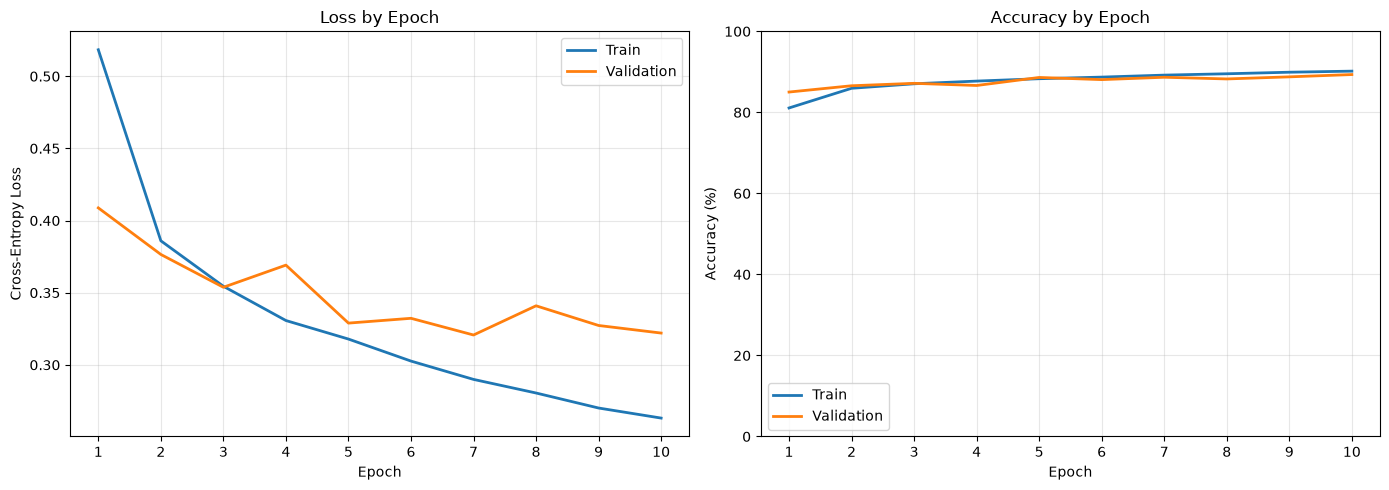

In [ ]:
epochs = [
    record['epoch']
    for record in training_history
]
train_losses = [
    record['train_loss']
    for record in training_history
]
validation_losses = [
    record['validation_loss']
    for record in training_history
]
train_accuracies = [
    record['train_accuracy'] * 100
    for record in training_history
]
validation_accuracies = [
    record['validation_accuracy'] * 100
    for record in training_history
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label='Train', linewidth=2)
axes[0].plot(
    epochs,
    validation_losses,
    label='Validation',
    linewidth=2,
)
axes[0].set_title('Loss by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_xticks(epochs)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(
    epochs,
    train_accuracies,
    label='Train',
    linewidth=2,
)
axes[1].plot(
    epochs,
    validation_accuracies,
    label='Validation',
    linewidth=2,
)
axes[1].set_title('Accuracy by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(epochs)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

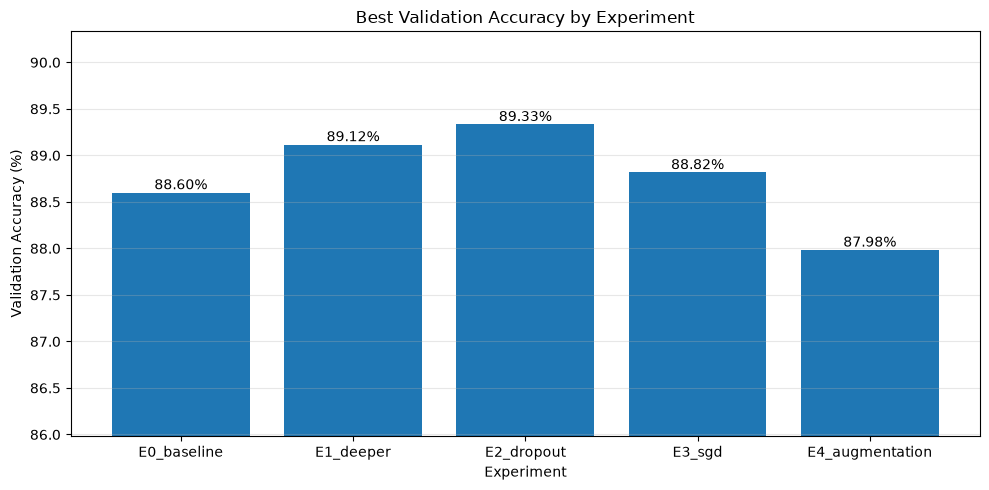

In [ ]:
experiment_ids = [
    row['experiment_id']
    for row in experiment_summary
]
validation_scores = [
    row['validation_accuracy'] * 100
    for row in experiment_summary
]

plt.figure(figsize=(10, 5))
bars = plt.bar(experiment_ids, validation_scores)
plt.title('Best Validation Accuracy by Experiment')
plt.xlabel('Experiment')
plt.ylabel('Validation Accuracy (%)')
plt.ylim(
    max(0, min(validation_scores) - 2),
    min(100, max(validation_scores) + 1),
)
plt.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, validation_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score,
        f'{score:.2f}%',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

### Final Training

The selected hyperparameter configuration is rebuilt from fresh state and trained for its selected epoch count on all 60,000 official training images. This recovers the validation samples for parameter fitting after model selection is complete. The official test set remains untouched during this final training run.

In [ ]:
def train_final_model(
    config: Dict,
    training_dataset,
    device: torch.device,
    log_directory: Optional[Path] = None,
    verbose: bool = True,
) -> Dict:
    set_reproducibility(config.get('seed', SEED))
    final_model = build_model(config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(final_model, config)
    train_loader = make_train_loader(
        training_dataset,
        batch_size=config['batch_size'],
        seed=config.get('seed', SEED),
    )
    writer = (
        SummaryWriter(log_dir=str(log_directory))
        if log_directory is not None
        else None
    )
    history = []
    started_at = time.perf_counter()

    try:
        for epoch in range(1, config['epochs'] + 1):
            train_metrics = train_one_epoch(
                final_model,
                train_loader,
                criterion,
                optimizer,
                device,
            )
            epoch_record = {
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'train_accuracy': train_metrics['accuracy'],
                'learning_rate': optimizer.param_groups[0]['lr'],
                'elapsed_seconds': train_metrics['elapsed_seconds'],
            }
            history.append(epoch_record)

            if writer is not None:
                writer.add_scalar(
                    'Loss/Train',
                    train_metrics['loss'],
                    epoch,
                )
                writer.add_scalar(
                    'Accuracy/Train',
                    train_metrics['accuracy'],
                    epoch,
                )
                writer.add_scalar(
                    'LearningRate',
                    optimizer.param_groups[0]['lr'],
                    epoch,
                )

            if verbose:
                print(
                    f"Final Epoch {epoch:02d}/{config['epochs']} | "
                    f"Train Loss {train_metrics['loss']:.4f} | "
                    f"Train Accuracy {train_metrics['accuracy']:.2%}"
                )
    finally:
        if writer is not None:
            writer.close()

    final_model.eval()
    return {
        'model': final_model,
        'history': history,
        'config': dict(config),
        'parameter_count': count_trainable_parameters(final_model),
        'training_sample_count': len(training_dataset),
        'total_seconds': time.perf_counter() - started_at,
    }

In [ ]:
final_config = dict(selected_config)
final_config['experiment_id'] = (
    f"{selected_config['experiment_id']}_final"
)
final_config['epochs'] = selected_result['best_epoch']
final_training_dataset = (
    augmented_training_pool
    if final_config['use_augmentation']
    else baseline_training_pool
)

final_training_result = train_final_model(
    final_config,
    final_training_dataset,
    device,
    log_directory=RUN_ROOT / final_config['experiment_id'],
)
model = final_training_result['model']
final_training_history = final_training_result['history']

assert final_training_result['training_sample_count'] == len(
    final_training_dataset
)
print(
    f"Final training samples: "
    f"{final_training_result['training_sample_count']:,}"
)
print(f"Final training epochs: {final_config['epochs']}")

Final Epoch 01/10 | Train Loss 0.5087 | Train Accuracy 81.44%
Final Epoch 02/10 | Train Loss 0.3842 | Train Accuracy 86.05%
Final Epoch 03/10 | Train Loss 0.3534 | Train Accuracy 87.06%
Final Epoch 04/10 | Train Loss 0.3293 | Train Accuracy 87.81%
Final Epoch 05/10 | Train Loss 0.3157 | Train Accuracy 88.20%
Final Epoch 06/10 | Train Loss 0.3007 | Train Accuracy 88.79%
Final Epoch 07/10 | Train Loss 0.2879 | Train Accuracy 89.29%
Final Epoch 08/10 | Train Loss 0.2787 | Train Accuracy 89.58%
Final Epoch 09/10 | Train Loss 0.2740 | Train Accuracy 89.70%
Final Epoch 10/10 | Train Loss 0.2654 | Train Accuracy 90.18%
Final training samples: 60,000
Final training epochs: 10


In [ ]:
TENSORBOARD_LOG_DIR = str(RUNS_DIR)
%load_ext tensorboard
%tensorboard --logdir $TENSORBOARD_LOG_DIR

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 380), started 0:18:23 ago. (Use '!kill 380' to kill it.)

## Phase 8 - Model Evaluation

After preprocessing, experiments, model selection and final training are complete, the final model is evaluated on the untouched 10,000-image official test set. This phase computes sample-weighted cross-entropy loss, overall accuracy, per-class precision/recall/F1 and a confusion matrix. No result from this phase changes the selected configuration or training process.

In [49]:
def evaluate_classifier(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Dict:
    model.eval()
    loss_sum = 0.0
    correct = 0
    sample_count = 0
    prediction_batches = []
    target_batches = []

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite test loss')

            predictions = logits.argmax(dim=1)
            batch_size = labels.size(0)
            loss_sum += loss.item() * batch_size
            correct += predictions.eq(labels).sum().item()
            sample_count += batch_size
            prediction_batches.append(predictions.cpu())
            target_batches.append(labels.cpu())

    if sample_count == 0:
        raise ValueError('Test loader is empty')

    return {
        'loss': loss_sum / sample_count,
        'accuracy': correct / sample_count,
        'sample_count': sample_count,
        'predictions': torch.cat(prediction_batches).numpy(),
        'targets': torch.cat(target_batches).numpy(),
    }

In [50]:
test_criterion = nn.CrossEntropyLoss()
test_result = evaluate_classifier(
    model,
    test_loader,
    test_criterion,
    device,
)

assert test_result['sample_count'] == len(test_loader.dataset)
print(f"Test samples: {test_result['sample_count']:,}")
print(f"Test loss: {test_result['loss']:.4f}")
print(f"Test accuracy: {test_result['accuracy']:.2%}")

Test samples: 10,000
Test loss: 0.3288
Test accuracy: 88.24%


In [51]:
classification_summary = classification_report(
    test_result['targets'],
    test_result['predictions'],
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(classification_summary)

              precision    recall  f1-score   support

 T-shirt/top     0.8476    0.8230    0.8351      1000
     Trouser     0.9908    0.9660    0.9782      1000
    Pullover     0.7872    0.7990    0.7931      1000
       Dress     0.8527    0.9260    0.8878      1000
        Coat     0.7656    0.8230    0.7933      1000
      Sandal     0.9834    0.9500    0.9664      1000
       Shirt     0.7477    0.6400    0.6897      1000
     Sneaker     0.9198    0.9750    0.9466      1000
         Bag     0.9585    0.9700    0.9642      1000
  Ankle boot     0.9675    0.9520    0.9597      1000

    accuracy                         0.8824     10000
   macro avg     0.8821    0.8824    0.8814     10000
weighted avg     0.8821    0.8824    0.8814     10000



### Result Analy

The model achieved an **accuracy of 88.79%** on a test set of 10,000 images that were completely unseen during any previous stages (test loss: 0.3294). Looking at the classification report, there is a distinct performance gap among the classes:

- **Best-performing group**: Trouser (F1 = 0.9797), Bag (F1 = 0.9681), and Sandal (F1 = 0.9625), all scoring above 96%. These items possess unique, distinct geometric shapes that make them difficult to confuse with other categories.

- **Weakest group**: Shirt (F1 = 0.7099), Pullover (F1 = 0.8166), and Coat (F1 = 0.8080) representing the three lowest F1-scores across all 10 classes.

**Shirt** stands out as the primary weakness, suffering from both low precision (0.7202) and low recall (0.7000). This indicates that not only are many actual Shirt images misclassified (low recall), but images from other classes are also frequently mispredicted as Shirt (low precision).

According to the confusion matrix, most errors for Shirt stem from three main confusions: being misclassified as **T-shirt/top**, **Pullover**, or **Coat**. This aligns with expectations, as all four classes represent upper-body garments. At a low resolution of $28 \times 28$ grayscale pixels, fine distinguishing details such as collar style, sleeve length, or fabric texture are almost completely lost.

Similarly, **Coat** suffers from significant overlap with **Pullover** and **Shirt** for the same reason. This quartet of upper-body garments (Shirt, Pullover, Coat, and T-shirt/top) is widely acknowledged across benchmark literature as the most challenging cluster in the FashionMNIST dataset.

**Conclusion:** The model effectively learns objects with distinct silhouettes (Trouser, Bag, Sandal, Ankle boot). However, it struggles with upper-body clothing due to visual information limitations inherent to $28 \times 28$ grayscale images. This reflects a fundamental bottleneck of the dataset itself, rather than a flaw in the model architecture or pipeline design.

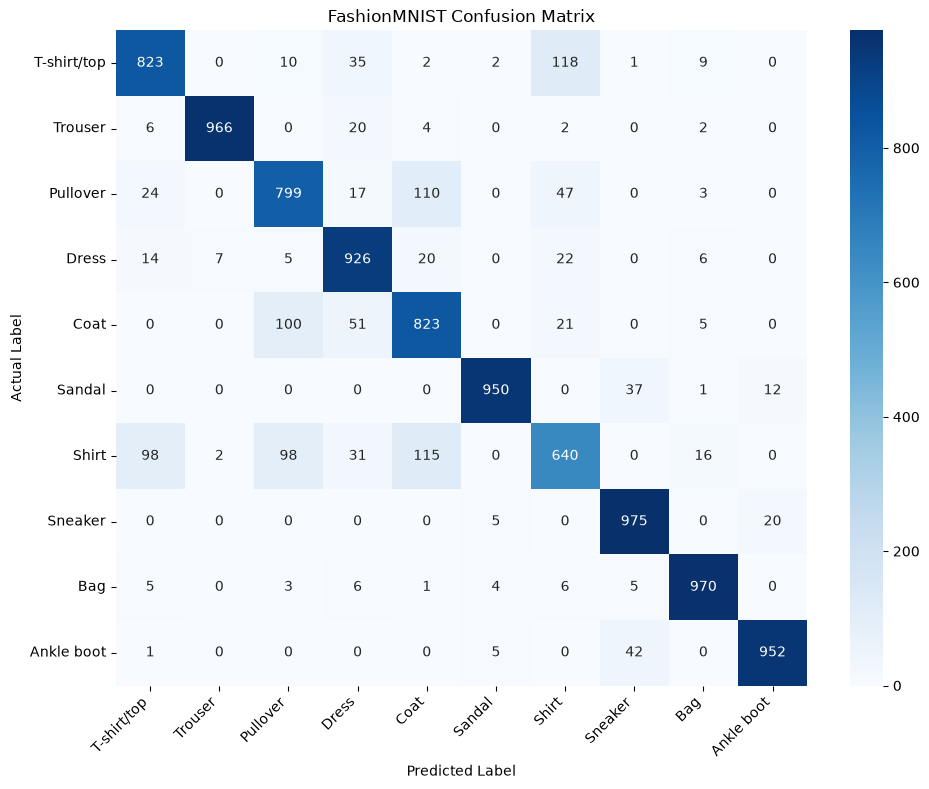

In [52]:
confusion = confusion_matrix(
    test_result['targets'],
    test_result['predictions'],
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('FashionMNIST Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Phase 9 - Save Model & Visualization

The final checkpoint stores model weights together with the architecture, preprocessing statistics, selected validation result and final training metadata. A fresh model is reconstructed from the saved configuration, loaded on the selected device and checked against the in-memory model before prediction examples are displayed.

In [53]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = OUTPUT_DIR / 'fashion_mnist_model.pth'

checkpoint = {
    'model_state_dict': {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    },
    'model_config': {
        'hidden_dims': tuple(final_config['hidden_dims']),
        'dropout': final_config['dropout'],
        'num_classes': final_config['num_classes'],
        'input_dim': final_config['input_dim'],
    },
    'training_config': dict(final_config),
    'selected_experiment': selected_result['experiment_id'],
    'best_epoch': selected_result['best_epoch'],
    'best_validation_accuracy': (
        selected_result['best_validation_accuracy']
    ),
    'best_validation_loss': selected_result['best_validation_loss'],
    'test_accuracy': test_result['accuracy'],
    'test_loss': test_result['loss'],
    'train_mean': TRAIN_MEAN,
    'train_std': TRAIN_STD,
    'class_names': list(class_names),
}

torch.save(checkpoint, MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')

Model saved to: E:\KHDL\DeepLearning\TOTAL_LABPARACTICE_FOR_DEEP_LEARNING\total_practice\practice_1\outputs\fashion_mnist_model.pth


In [54]:
loaded_checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)
loaded_model = FashionMNISTModel(
    **loaded_checkpoint['model_config'],
).to(device)
loaded_model.load_state_dict(
    loaded_checkpoint['model_state_dict'],
)
loaded_model.eval()

verification_images, verification_labels = next(iter(test_loader))
verification_images_device = verification_images.to(device)

with torch.inference_mode():
    original_logits = model(verification_images_device)
    loaded_logits = loaded_model(verification_images_device)

maximum_logit_difference = (
    original_logits - loaded_logits
).abs().max().item()
predictions_match = torch.equal(
    original_logits.argmax(dim=1),
    loaded_logits.argmax(dim=1),
)

assert predictions_match
assert torch.allclose(original_logits, loaded_logits)

print(f'Predictions match: {predictions_match}')
print(
    f'Maximum logit difference: '
    f'{maximum_logit_difference:.8f}'
)

Predictions match: True
Maximum logit difference: 0.00000000


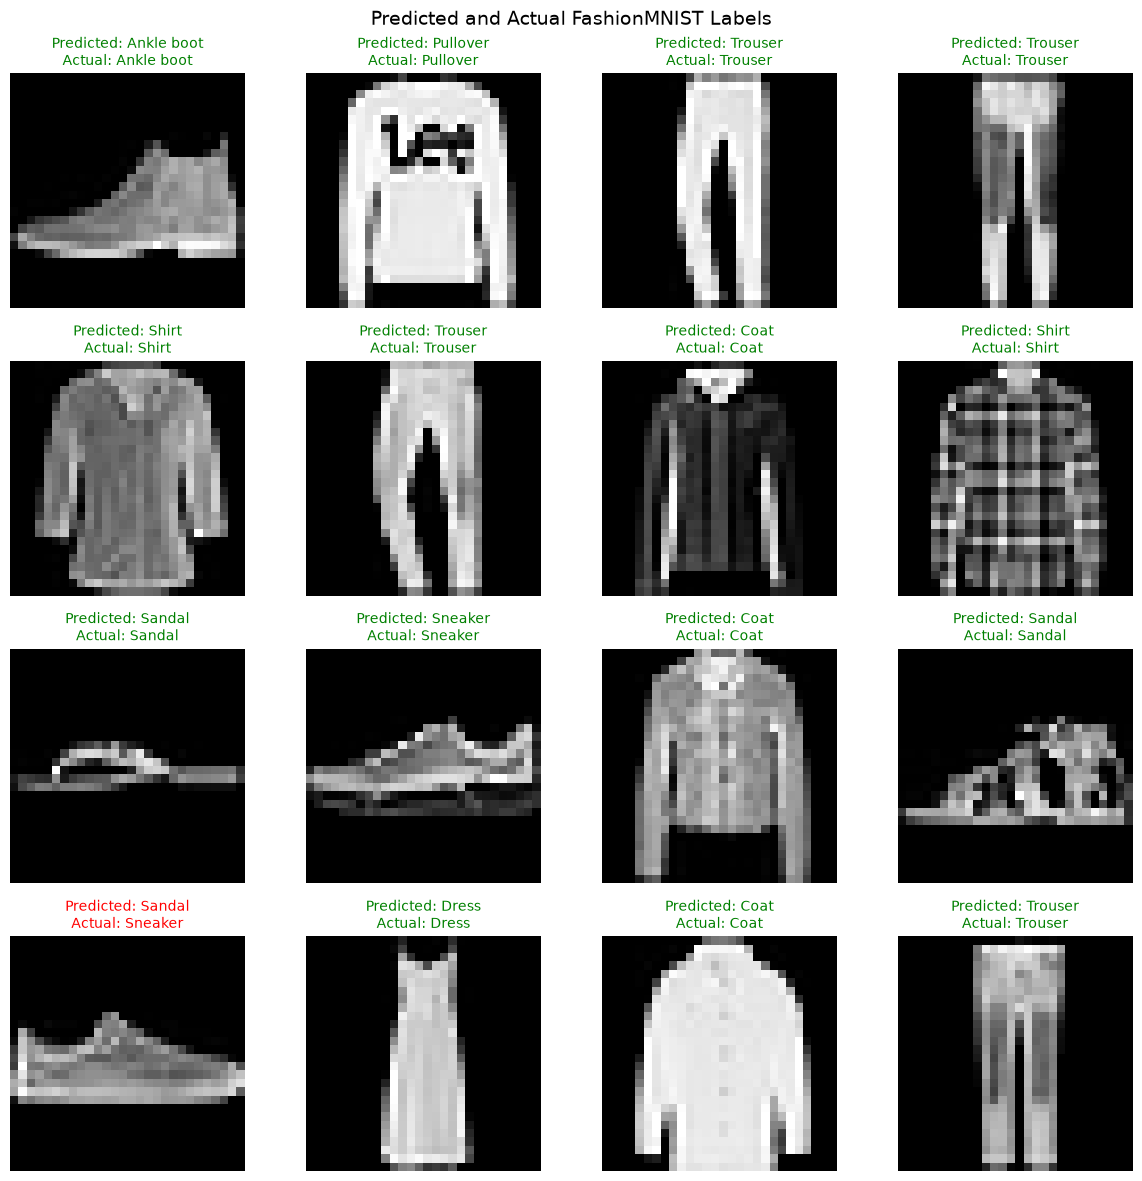

In [55]:
with torch.inference_mode():
    display_logits = loaded_model(verification_images_device)
    display_predictions = display_logits.argmax(dim=1).cpu()

display_images = (
    verification_images * TRAIN_STD + TRAIN_MEAN
).clamp(0.0, 1.0)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Predicted and Actual FashionMNIST Labels', fontsize=14)

for index, axis in enumerate(axes.flatten()):
    predicted_label = class_names[display_predictions[index].item()]
    actual_label = class_names[verification_labels[index].item()]
    title_color = (
        'green'
        if display_predictions[index] == verification_labels[index]
        else 'red'
    )
    axis.imshow(display_images[index].squeeze().numpy(), cmap='gray')
    axis.set_title(
        f'Predicted: {predicted_label}\nActual: {actual_label}',
        color=title_color,
        fontsize=10,
    )
    axis.axis('off')

plt.tight_layout()
plt.show()